STP-RRT* algorithm gives the CasADi solver an initial guess for the optimal path

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import STP_RRTStar_Occluding_Obs
import Dynamic
import numpy as np
import casadi as ca
import matplotlib.patches as patches
from IPython.display import HTML
from scipy.interpolate import splprep, splev
import importlib
import csv
import json
from scipy.interpolate import interp1d
from Camera import Camera
import time
import convex_map_PURT as convex_map
from typing import Dict, List, Tuple, Optional
import random
import math
from matplotlib.path import Path
from shapely.geometry import MultiPoint, Polygon, MultiPolygon, GeometryCollection

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar_Occluding_Obs)
from STP_RRTStar_Occluding_Obs import STP_RRTStar_Occluding_Obs as Rrt

In [3]:
# This version is setting up a simulation for PURT

# Randomization Seed
seed_value = 7777

# 5318008 has one double turn, but otherwise pretty solid
# 7777 is pretty good


random.seed(seed_value)
np.random.seed(seed_value)



# -------------------------------------------------------------------------------------------------------
# Map Parameters
# -------------------------------------------------------------------------------------------------------

map_size_original = [-0.5692, 5.695, -6.960, -144.6] # [xmin, xmax, ymin, ymax]
map_translate = [map_size_original[0], map_size_original[2]] # [x_shift, y_shift]
map_size = [map_size_original[0]-map_translate[0], map_size_original[1]-map_translate[0], map_size_original[2]-map_translate[1], map_size_original[3]-map_translate[1]]
x0_1 = [-0.252075-map_translate[0], -6.4562-map_translate[1], 0] # Start at Point 1 (West side of map)
x0list = [x0_1]
xf = [5.399-map_translate[0], -0.9407-map_translate[1], 0] # Arrive at Runway (to blow up a plane)
# xf = [10, 5, 0] # testing occlusion
MAP_W, MAP_H = map_size[1]-map_size[0], map_size[3]-map_size[2] # Width and Height of the map



# -------------------------------------------------------------------------------------------------------
# Camera Parameters
# -------------------------------------------------------------------------------------------------------

# Camera positions
cam_x = [.266425-map_translate[0], -3.2381-map_translate[0], 2.2416-map_translate[0]] # list .
cam_y = [-4.4014-map_translate[1], -5.945025-map_translate[1], -1.294525-map_translate[1]]
dynamic_obstacle_pos = []
for i in range(len(cam_x)):
    dynamic_obstacle_pos.append([cam_x[i], cam_y[i]])

# Surveillance Pattern Parameters
tilt_limit = [] #[lower, upper]
tilt_limit.append([np.deg2rad(90), np.deg2rad(-90)])
tilt_limit.append([np.deg2rad(0), np.deg2rad(180)])
tilt_limit.append([np.deg2rad(270), np.deg2rad(90)])

init_angles = []
for i in range(len(cam_x)):
    init_angles.append((tilt_limit[i][0]+tilt_limit[i][1])/2)
# init_angles = [(tilt_limit[0][0]+tilt_limit[0][1])/2, (tilt_limit[1][0]+tilt_limit[1][1])/2, (tilt_limit[2][0]+tilt_limit[2][1])/2] 
# ^^^ Currently setting these to be the midpoints of the angluar range ^^^

# Source for Reolink camera specs: https://reolink.com/us/product/rlc-823a-16x/#specifications
fov_ang = np.deg2rad(54.2) #  Horizontal: 54.2°-3.6°, Vertical: 41.7°-2.1°
fov_rng = 0.5 # this was at 8 for the PURT scenario
# allegedly, the max range is 80 m in night mode. Likely, this is for tracking a human, so it might be smaller for something drone-sized.
# also, this depends on the focal length, which changes the fov angle.
#npanSpeed = [-np.deg2rad(0.45), np.deg2rad(0.45), -np.deg2rad(0.45)] # source: Jefferson
panSpeed = [-np.deg2rad(0.225), -np.deg2rad(0.225), -np.deg2rad(0.225)] # source: Jefferson
# the camera increment is 0.225 degrees, panning at 2 increments per second
cam_t = [1000, 1, 500] # [camera_period, camera_increment, some unused variable]
# I'm not convinced that camera_period affects anything

# Camera Dictionary
cam_dict = {}
cam_dict['n'] = len(cam_x)
cam_dict['x'] = cam_x
cam_dict['y'] = cam_y

# Camera Spec
cam_period = cam_t[0]
cam_increment = cam_t[1]
cam_dict['spec'] = {}
cam_dict['spec']['init_angle'] = init_angles
cam_dict['spec']['bound'] = tilt_limit
cam_dict['spec']['fov'] = [fov_ang, fov_rng]
cam_dict['spec']['cam_time'] = [cam_period, cam_increment]
cam_dict['spec']['panspeed'] = panSpeed # This is just in here because it was in Jeff's code

# BUILD 'cam_dict_full'
# Replicates 'cam_dict' structure
cam_dict_full = {
    "n": len(cam_x),
    "x": np.array(cam_x, dtype=float),
    "y": np.array(cam_y, dtype=float),
    "spec": {
        "init_angle": init_angles,                    # List of floats (radians)
        "bound": np.array(tilt_limit, dtype=float),       # Numpy array of [+, -] limits
        "fov": [float(fov_ang), float(fov_rng)],       # [fov_angle, max_dist]
        "cam_time": [float(cam_period), float(cam_increment)], 
        "panspeed": panSpeed                         # List of floats
    }
}



# -------------------------------------------------------------------------------------------------------
# Adding Buildings
# -------------------------------------------------------------------------------------------------------

# Building Vertices
# Format: List of (x, y) tuples
# b1 = [(-0.745, -10.251), (0.555, -10.227), (0.563, -10.6), (-0.731, -10.624)] # Terminal building
# b2 = [(8.624, -10.046), (9.47, -10.069), (9.447, -10.901), (8.617, -10.878)] # PURT building
# b3 = [(3.17, -3.333), (4.465, -3.27), (4.49, -3.641), (3.191, -3.714)] # Control tower
b1 = [(-0.06919824133375395, 1.835501758666246), (0.844298241333754, 1.835501758666246), (0.844298241333754, 3.332298241333754), (-0.06919824133375395, 3.332298241333754)]
b2 = [(2.843301758666246, -0.01739824133375393), (3.764798241333754, -0.01739824133375393), (3.764798241333754, 2.097098241333754), (2.843301758666246, 2.097098241333754)]
b3 = [(4.802101758666247, 2.963701758666246), (5.701198241333754, 2.963701758666246), (5.701198241333754, 4.2888982413337535), (4.802101758666247, 4.2888982413337535)]









# shift by map_translate
# b1 = [(x - map_translate[0], y - map_translate[1]) for (x, y) in b1]
# b2 = [(x - map_translate[0], y - map_translate[1]) for (x, y) in b2]
# b3 = [(x - map_translate[0], y - map_translate[1]) for (x, y) in b3]   
# b4 = [(7,4), (12,4), (12,2), (7,2)] # Building to test occlusion

#manual_buildings = [b1, b2, b3, b4]
manual_buildings = [b1, b2, b3]


# -----------------------------------------------------------------------------------------------------
# Making the dictionaries
# -----------------------------------------------------------------------------------------------------

# BUILD 'map_in_full'
# Replicates the structure of 'map_in' from generate_map
st = {
    # Map boundaries: [xmin, xmax, ymin, ymax]
    "size": np.array([0.0, MAP_W, 0.0, MAP_H], dtype=float),
    "n": len(manual_buildings)
}

# Add buildings with string keys '0', '1', etc.
for i, poly in enumerate(manual_buildings):
    st[str(i)] = np.array(poly, dtype=float)

# FINALIZE 'map_in_full'
# Add camera count metadata to the map structure
map_in_full = {
    "st": st,
    "n": float(cam_period),
    "ncam": int(cam_dict_full["n"])
}

# Extract map_in and cam_dict in the expected format
map_in = {
    'st': map_in_full['st'], # 'st' for static obstacles?
    'n': map_in_full['n'],
    'ncam': map_in_full['ncam']
}

map_in['ncam'] = len(cam_x)
map_in['st']['size'] = np.array([map_size[0], map_size[1], map_size[2], map_size[3]])
num_existing_obs = map_in['st']['n']

# Adding camera obstacles to static Map
r_cyl = 0.5
map_in['st']['n'] = len(cam_x) + num_existing_obs # total number of obstacles
## Previous version that does circles around the cameras, replacing with squares for RRT
# for i in range(len(cam_x)):
#     map_in['st'][str(i)] = np.array([cam_x[i], cam_y[i], r_cyl])

# New version with squares around the cameras
for i in range(len(cam_x)):
    cx, cy = cam_x[i], cam_y[i]
    r = r_cyl
    # Define a square around the center [x, y] with "radius" r
    # Format: [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    vertices = [
        [cx - r, cy - r],
        [cx + r, cy - r],
        [cx + r, cy + r],
        [cx - r, cy + r]
    ]
    # Save the new obstacle using the next available index
    # We use str(num_existing_obs + i) so we don't overwrite '0', '1', etc.
    map_in['st'][str(num_existing_obs +i)] = np.array(vertices)

# # map_in['st']['0'] = np.array([cam_x[0], cam_y[0], r_cyl])
# # map_in['st']['1'] = np.array([cam_x[1], cam_y[1], r_cyl])
# # map_in['st']['2'] = np.array([cam_x[2], cam_y[2], r_cyl])

# # Dynamic Map
# # This is a continuous function that generates camera FOV coverages
# # Input is map_in, and time input t_in
map_in['n'] = cam_t[0] # camera period. This is needed for DynamicMap class (it's dumbly named n)

cameras_dict_copilot = []
for i in range(cam_dict['n']):
    cam_x_dict = cam_dict['x'][i]
    cam_y_dict = cam_dict['y'][i]
    lower = cam_dict['spec']['bound'][i][0]
    upper = cam_dict['spec']['bound'][i][1]
    amplitude = 0.5 * (upper - lower)
    center = cam_dict['spec']['init_angle'][i] # ASSUMING THAT INITIAL ANGLE IS CENTER ANGLE
    period = cam_dict['spec']['cam_time'][0]
    frequency = 1 / period  # Use Hz for animation
    init_angle = cam_dict['spec']['init_angle'][i]
    # phase_offset = np.arctan2(init_angle - center, amplitude)
    phase_offset = 0 # Assuming that all cameras start at center of angular range
    panspeed = cam_dict['spec']['panspeed'][i]

    cameras_dict_copilot.append({
        'pos': [cam_x_dict, cam_y_dict],
        'amplitude': amplitude,
        'frequency': frequency,
        'phase': phase_offset,
        'center': center,
        'range': fov_rng,
        'panspeed': panspeed
    })

''' Skipping the random obstacle and camera generation from convex_map'''
# num_cams = 0 # number of cameras to be randomly placed
# num_obs = 0 # number of obstacles to be randomly placed 
# 7 used for 12/12/25 animation
# # Generate the map using the new function
# map_in_full, cam_dict_full = convex_map.generate_map(
#     map_size=(MAP_W, MAP_H),
#     num_buildings=num_obs, # Number of buildings
#     num_sensors=num_cams,   # Number of PTZ cameras
#     min_center_sep=1,
#     rng_seed=7 #7 for 11/7/25 animation and 12/10/25 animation
# )

# Re-define map_size for CasADi bounds
map_size = [map_in['st']['size'][0], map_in['st']['size'][1], map_in['st']['size'][2], map_in['st']['size'][3]]

# Passing to DynamicMap
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap



# -------------------------------------------------------------------------------------------------------
# RRT Settings
# -------------------------------------------------------------------------------------------------------

iter_max = 1000     # maximum number of iterations for the tree. This currently isn't being enforced anywhere
vmax = 0.5            # max velocity for each point, based on crazyflie forum: https://forum.bitcraze.io/viewtopic.php?t=5115
max_time = 3        # tune this
prox = [vmax, max_time] # proximity for connection [position, time] 
x0 = x0list[0]          # start point
nPartition = 5          # number of trees from the end point
compTimeLimit = 300     # computation time limit (sec)

# Vehicle Spec for RRT
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1 # used for obstacle clearance

min_dist = np.sqrt((x0_1[0]-xf[0])**2 + (x0_1[1]-xf[1])**2)
min_time = min_dist/vmax        # time to fly in a straight line at max speed
#tf0 = min_time                  # lower bound on end time randomization
tf0 = 35
tfn = 40                      # upper bound on end time randomization

test_rrt = Rrt(vmax, x0, xf, map_size, vehicle, cam_dict, dmap, max_time, map_in, prox)

Occluding Obstacle STP-RRTStar 2/20/26 9:03 PM version initialized


In [4]:
run_RRT = True

if run_RRT:
    success_bool, computation_time, total_path_distance, total_path_time, \
        success, path, V_start, V_goal, E_start, E_goal = \
            test_rrt.path_planning_main(x0, nPartition, compTimeLimit, tf0, tfn)

    # Save camera parameters to a JSON file
    rrt_parameters = {
        "success_bool": success_bool,
        "computation_time": computation_time, 
        "total_path_distance": total_path_distance, 
        "total_path_time": total_path_time,
        "success": success, 
        "path": path, 
        "V_start": V_start, 
        "V_goal": V_goal, 
        "E_start": E_start, 
        "E_goal": E_goal,
    }
    with open("rrt_parameters.json", "w") as f:
        json.dump(rrt_parameters, f, indent=4)
    print("RRT parameters saved to rrt_parameters.json.")
else:
    # Loading rrt parameters
    with open("rrt_parameters.json", "r") as f:
        rrt_parameters = json.load(f)

    success_bool = rrt_parameters['success_bool']
    computation_time = rrt_parameters["computation_time"]
    total_path_distance = rrt_parameters["total_path_distance"]
    total_path_time = rrt_parameters["total_path_time"]
    success = rrt_parameters["success"]
    path = rrt_parameters["path"]
    V_start = rrt_parameters["V_start"]
    V_goal = rrt_parameters["V_goal"]
    E_start = rrt_parameters["E_start"]
    E_goal = rrt_parameters["E_goal"]

k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0
k: 0


KeyboardInterrupt: 

In [ ]:
# Checking that the path obeys the maximum speed constraint

def verify_path_speed(path, vmax):
    """
    Verifies if any segment of the path exceeds vmax.
    Args:
        path: List of [x, y, t] points.
        vmax: Maximum allowed velocity.
    """
    # Convert to numpy array for easier calculation
    path_arr = np.array(path)
    
    # Calculate differences between consecutive points (dx, dy, dt)
    diffs = np.diff(path_arr, axis=0)
    dx = diffs[:, 0]
    dy = diffs[:, 1]
    dt = diffs[:, 2]

    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    
    # Avoid division by zero issues
    # (If dt is 0, the speed is effectively infinite if dist > 0)
    dt_safe = np.maximum(dt, 1e-8) 
    
    # Calculate speeds: v = d / t
    speeds = distances / dt_safe

    # Identify violations
    # Using a small tolerance (1e-5) for floating point comparisons
    violation_indices = np.where(speeds > vmax + 1e-5)[0] 
    
    if len(violation_indices) > 0:
        print(f"⚠️ Speed Violation Detected: {len(violation_indices)} segments exceed vmax ({vmax})")
        print(f"   Maximum Speed Found: {np.max(speeds):.4f}")
        
        # Print the first few violations
        print("   First 3 violations:")
        for i in violation_indices[:3]:
            print(f"     Seg {i}->{i+1}: Speed={speeds[i]:.2f}, Dist={distances[i]:.2f}, Time={dt[i]:.4f}")
    else:
        print(f"✅ Path is valid. Max speed found: {np.max(speeds):.4f} (Limit: {vmax})")

# Run the check on your variables
if path is not None:
    verify_path_speed(path, vehicle['v'])

✅ Path is valid. Max speed found: 1.0000 (Limit: 1)


In [ ]:
# Helper function to compute Half-Space parameters for a convex polygon
def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes A and b matrices for Ax <= b representation of a convex polygon.
    The constraint for avoidance will be A*p >= b + margin, or b - A*p <= -margin
    where p is the agent position.
    
    This function computes the *inward* pointing normal a_i and the offset b_i
    such that a_i^T * p <= b_i defines the INSIDE of the polygon.
    """
    
    # --- FIX 1: Ensure Polygon Vertices are Sorted (CCW) ---
    # Randomly generated vertices might be unordered, causing crossing edges.
    # this finds a point that is guaranteed to be inside the polygon (not necessarily the actual centroid)
    sorting_centroid = np.mean(poly_vertices, axis=0)
    # Calculate angles of all vertices relative to centroid
    angles = np.arctan2(poly_vertices[:, 1] - sorting_centroid[1], poly_vertices[:, 0] - sorting_centroid[0])
    # Sort vertices by angle to ensure valid perimeter edges
    sort_idx = np.argsort(angles)
    poly_vertices = poly_vertices[sort_idx] # sorted list of vertices

    A_list, b_list = [], []
    N_verts = len(poly_vertices)
    
    # Calculate centroid for inward/outward check
    # Note: polygon_centroid from convex_map uses NumPy but poly_vertices is a list of tuples initially
    # Ensure consistency; if poly_vertices is a NumPy array of (N, 2), this is fine.
    # We will use the centroid function from the imported convex_map
    # centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])

    # CORRECTED CODE: Ensure poly_vertices is a list of tuples before passing to polygon_centroid
    # The map_in entry is a numpy array of arrays/lists (e.g., [[x1, y1], [x2, y2], ...])
    # We convert it back to the expected List[Tuple[float, float]] format for the utility function.
    # Let's ensure the inner elements are float/int pairs:
    if poly_vertices.ndim == 2:
        # This is a (N_verts, 2) array. Convert to a list of tuples.
        centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
    else:
        # This must be the old [x, y, r] circular obstacle format that was accidentally left
        raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
    
    for i in range(N_verts):
        v1 = poly_vertices[i]
        v2 = poly_vertices[(i + 1) % N_verts]
        
        # Edge vector (v2 - v1)
        ex, ey = v2[0] - v1[0], v2[1] - v1[1]
        
        # Candidate normal vector 1: n1 = (-ey, ex)
        # This is a counter-clockwise rotation from the edge vector (pointing left relative to edge direction v1->v2)
        n1 = np.array([-ey, ex])
        
        # Normalizing n1
        norm_n1 = np.linalg.norm(n1)
        n1 = n1 / (norm_n1 + 1e-6) # avoiding division by zero

        # Check which normal points *inward* (toward the centroid)
        mid_point = (v1 + v2) / 2.0
        vec_to_centroid = np.array(centroid) - mid_point
        
        # # OLD WAY WITH NORMAL VECTORS POINTING INWARD
        # # If the dot product is negative, n1 points away from the centroid (outward)
        # # We want the *inward* normal, which points towards the centroid
        # if np.dot(n1, vec_to_centroid) < 0:
        #     # n1 is outward, so the inward normal is -n1
        #     a_i = -n1
        # else:
        #     # n1 is inward
        #     a_i = n1

        # --- FIX: ENSURE OUTWARD NORMAL ---
        # We want the normal to point AWAY from the centroid.
        # So dot product with vec_to_centroid should be NEGATIVE.
        
        if np.dot(n1, vec_to_centroid) < 0:
            # n1 points OUT (Good!)
            a_i = n1
        else:
            # n1 points IN (Bad, flip it)
            a_i = -n1


            
        # Calculate the offset b_i using a point on the boundary (v1)
        # This is just a projection of the vertex vector onto the normal vector to find the distance from the origin
        b_i = np.dot(a_i, v1)
        
        A_list.append(a_i)
        b_list.append(b_i)

    # FINAL STEP: Enforce dimensions here
    A_out = np.array(A_list)       # Shape becomes (N, 2) automatically
    b_out = np.array(b_list)       # Shape starts as (N,)
    
    # Reshape immediately before returning
    b_out = b_out.reshape(-1, 1)   # Shape becomes (N, 1)

    return A_out, b_out

    # # Return as NumPy arrays for CasADi/NumPy operations
    # return np.array(A_list), np.array(b_list)


def inflate_polygon_for_casadi(vertices, radius):
    """
    Inflates a polygon by the vehicle radius.
    Uses a mitre join (join_style=2) to prevent rounded corners,
    keeping the number of half-space constraints low for CasADi.
    
    Args:
        vertices: List of (x,y) tuples or (N, 2) numpy array of the obstacle.
        radius: float, the margin to inflate by (vehicle['radius']).
        
    Returns:
        numpy array of the inflated polygon vertices (N, 2).
    """
    # Create the shapely polygon from the vertices
    poly = Polygon(vertices)
    
    # Buffer the polygon. 
    # join_style=2 ensures sharp corners instead of rounded ones.
    inflated_poly = poly.buffer(radius, join_style=2)
    
    # Extract the new coordinate points
    # .exterior.coords repeats the first point at the end, so we slice [:-1]
    inflated_coords = list(inflated_poly.exterior.coords)[:-1]
    
    return np.array(inflated_coords)


# Pre-calculate A and b for all buildings
obstacle_constraints = []
uav_radius = vehicle['radius']

for i in range(map_in['st']['n']):
    # Get original vertices
    orig_vertices = map_in['st'][str(i)]
    
    # Inflate ONLY for the collision constraints
    inflated_vertices = inflate_polygon_for_casadi(orig_vertices, uav_radius)
    
    # Generate A and b from the INFLATED vertices
    A, b = get_polygon_half_space_constraints(inflated_vertices)
    obstacle_constraints.append({'A': A, 'b': b})

# for i in range(map_in['st']['n']):
#     # map_in['st'][str(i)] is an (N_verts, 2) numpy array of vertices

#     poly_vertices = map_in['st'][str(i)]
#     A, b = get_polygon_half_space_constraints(poly_vertices)
#     obstacle_constraints.append({'A': A, 'b': b})

print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")

Pre-processed 6 convex polygon obstacles.


<Figure size 5000x5000 with 0 Axes>

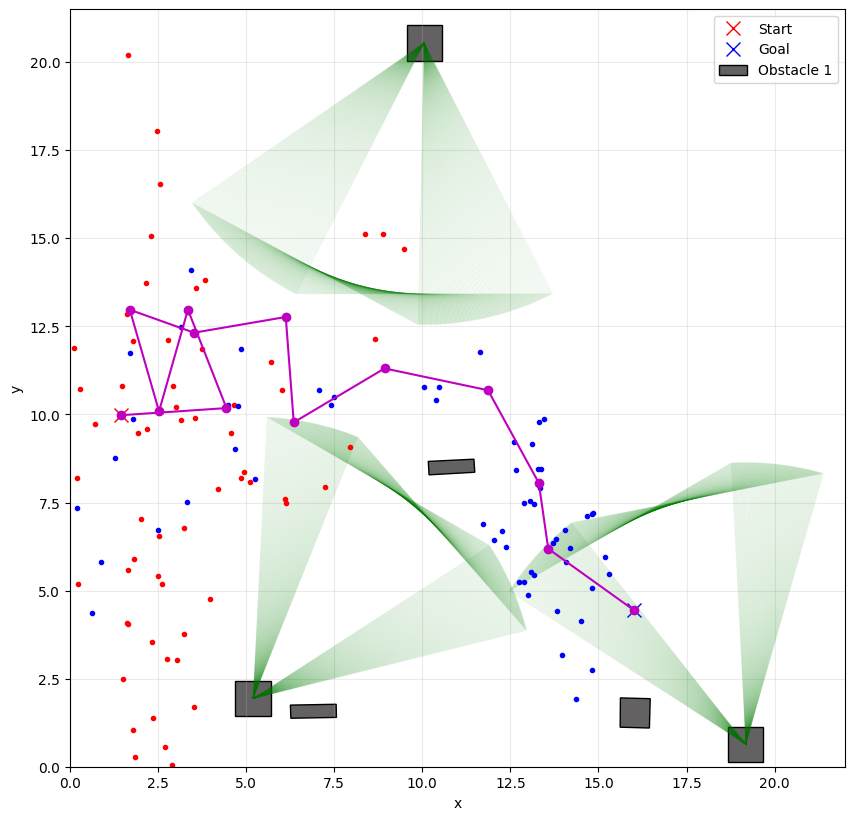

In [ ]:
# UNCOMMENT in Jupyter
%matplotlib inline 

'''Uncomment this to go back to getting the paths from the files (From the monte carlo simulation)'''
# if path_type_string == "naive":
#     end_point_naive = [xf[0], xf[1], min_time*5]
#     path = [x0_1, end_point_naive]
# else:
#     path = path_data[path_type_string][str(scenario_key)]  # or whichever key you want to use

# V_goal = path[-1]
# V_start = path[0]

# --------------------------- RRT Visualization ------------------------------------------------#
figure = plt.figure(figsize=(10, 10), dpi = 500)
fig, ax = plt.subplots(figsize=(10, 10))
pointmarker = 10

plt.plot(x0list[0][0], x0list[0][1], 'xr', markersize=pointmarker, label='Start')
plt.plot(xf[0], xf[1], 'xb', markersize=pointmarker, label='Goal')

# Timestamps for fov triangles
num_fov = int(np.ceil(tfn))  # number of time steps (Currently at 5 Hz sampling)
if path != None:
    start_time = path[0][2]
    end_time = path[len(path)-1][2]
else:
    start_time = 0
    end_time = tfn*10
#t_fov = np.linspace(start_time, end_time, num_fov+1)
t_fov = np.linspace(0, 20, 101) # Original code from Jefferson

# # helper funciton to pass a camera dictionary with only the fov bounds and initial angle for that particular camera
# def make_single_cam_dict(cam_dict, cam_index):
#     return {
#         'x': [cam_dict['x'][cam_index]],
#         'y': [cam_dict['y'][cam_index]],
#         'n': 1,
#         'spec': {
#             'bound': cam_dict['spec']['bound'][cam_index],
#             'fov': cam_dict['spec']['fov'],
#             'cam_time': cam_dict['spec']['cam_time'],
#             'init_angle': cam_dict['spec']['init_angle'][cam_index]
#         }
#     }


# for t in t_fov:
#     for ii in range(len(cam_x)):
#         # Preprocess cam_dict for this camera
#         cam_dict_single = make_single_cam_dict(cam_dict, ii)

#         # Create a temporary DynamicMap with just one camera
#         temp_map = {
#             'n': cam_dict['spec']['cam_time'][0],  # camera period
#             'ncam': 1,
#             'x': [cam_x[ii]],
#             'y': [cam_y[ii]]
#         }

#         temp_dmap = DynamicMap(temp_map, cam_dict_single)
#         cameras_dmap = temp_dmap.gen_cam(t)

#         cam_i_fov_poly = cameras_dmap['0']['FOV_Poly']  # only one camera

#         cx, cy = cam_i_fov_poly.exterior.xy
#         plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)



# # Old version with issues passing a full list to the dmap
# for t in t_fov:
#     for ii in range(len(cam_x)):
#         cameras_dmap = dmap.gen_cam(ii, t)
#         #ncam = cameras_dmap['n']
#         cam_i_fov_poly = cameras_dmap[str(ii)]['FOV_Poly']
#         cx, cy = cam_i_fov_poly.exterior.xy
#         plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)

for t in t_fov:
    for ii in range(len(cam_x)):
        cameras_dmap = dmap.gen_cam(ii, t)
        cam_i_fov_poly = cameras_dmap[str(ii)]['FOV_Poly']
        cx, cy = cam_i_fov_poly.exterior.xy
        plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)
        
building_alpha = 1
# Define colors for the convex obstacles
obstacle_colors = ["#636161", "#636161"] # Gray colors
camera_color = ['#008000', '#7FFF00', '#9ACD32', "#00EAFF", "#065AEC", "#9406EC", "#EC06EC", "#EC0694", "#EC8806", "#EC0E06"]

# for ii in range(map_in['st']['n']):
#     ibuilding = map_in['st'][str(ii)]
#     #camera_circle = plt.Circle((ibuilding[0], ibuilding[1]), ibuilding[2], color=camera_color[ii], alpha=building_alpha, clip_on=False, label='PTZCAM0'+str(ii+1))
#     #ax.add_patch(camera_circle) 

for ii in range(map_in['st']['n']):
    # map_in['st'][str(ii)] contains the (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(ii)]
    
    # Create a Polygon patch from the vertices
    # Use a solid fill color (facecolor) and a darker edge (edgecolor)
    polygon_patch = patches.Polygon(
        poly_vertices,
        closed=True,
        facecolor=obstacle_colors[ii % len(obstacle_colors)], # Cycle through colors
        edgecolor='k',
        linewidth=1,
        alpha=building_alpha,
        label=f'Obstacle {ii+1}' if ii == 0 else "" # Only label the first one for legend
    )
    ax.add_patch(polygon_patch)


# Plot RRT
for vi in V_start:
    plt.plot(vi[0], vi[1], '.r')
for i in range(len(V_goal)):
    for vi in V_goal[str(i)]:
        plt.plot(vi[0], vi[1], '.b')


# Plot Path
if path is not None:
    for pi in path:
        plt.plot(pi[0], pi[1], 'om')

    for pii in range(len(path)-1):
        p1 = path[pii]
        p2 = path[pii+1]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], '-m')


plt.grid(alpha=0.25)
plt.axis('square')
# Plot Limits
plt.xlim(map_size[0], map_size[1])
plt.ylim(map_size[2], map_size[3])
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()
# fig.savefig('crazyflie_test_map.png')


CasADi Optimization

In [ ]:
# CasADi

# Cost function: at each time step, take the pointwise probability of detection k(x,t) where x is the
# position and t is the time. 
# P_detection = 1 - P_not_detected
# P_not_detected = (1-k(x1,t1))*(1-k(x2,t2))*(1-k(x3,t3))*...
# P_not_detected = PI(1-k(x_i, t_i))
# log(P_not_detected) = log(PI(1-k(x_i, t_i)))
# log(P_not_detected) = log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ...
# So, at each time step, take the pointwise detectability, then take the log of it, then add it to the running cost
# CasADi should try to MAXIMIZE this summation of logarithms to minimize the probability of detection

# Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# exp(log(P_not_detected)) = P_not_detected
# P_detected = 1 - P_not_detected




tic = time.time() # Timing the optimization part of the program

# # Old alpha variable for Cartee (2019) detection function
# alpha = 99/(fov_rng**2)#this is the distance decay variable (higher = more decay) 
# # ^ (Currently, this does the math to make the k value <=0.01 outside of fov range)
# # Gemini alpha calculation: alpha ~= 99/range_max^2

beta_distance = 1 # slope parameter for Akbarzadeh (2013) distance decay function, recommended: 30
beta_pan = 60 # slope parameter for Akbarzadeh (2013) pan angle decay function, recommended: 60
t_distance = fov_rng/2 # distance at which the detectability is 0.5 for the distance decay function
k_shadow = 50 # "k" parameter for the shadow function. Higher means a sharper transition
FPS = 25 # Camera frames per second (same source as camera panning: https://reolink.com/us/product/rlc-823a-16x/#specifications)


# alpha = alpha = 99/(fov_rng**2)/10 #increasing detectability to prove whether the obstacle occlusion is working
# C_visibility = 100 #this is the steepness of visibility transition (higher = sharper transition)


#MAX_K_VALUE = 0.9999

'''Helper functions:'''

def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
    """
    Interpolates the original STP-RRT path using time-based interpolation,
    preserving the original speed profile.

    Parameters:
    - rrt_path: list of [x, y, t] points from STP-RRT
    - num_points: number of interpolated points to generate

    Returns:
    - x_interp: list of interpolated x positions
    - y_interp: list of interpolated y positions
    - t_interp: list of interpolated time values
    """
    rrt_array = np.array(rrt_path)
    x = rrt_array[:, 0]
    y = rrt_array[:, 1]
    t = rrt_array[:, 2]

    # Create interpolation functions for x(t) and y(t)
    fx = interp1d(t, x, kind='linear')
    fy = interp1d(t, y, kind='linear')

    # Generate evenly spaced time values
    t_interp = np.linspace(t[0], t[-1], num_points)

    # Interpolate positions
    x_interp = fx(t_interp)
    y_interp = fy(t_interp)

    return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()


# This is the function that calculates the shadow lines for a single camera and a single obstacle.
def get_shadow_lines(camera_pos, obs_vertices):
    """
    Calculates the a, b, c coefficients for the lines bounding the shadow wedge.
    Returns a list of tuples: [(a1, b1, c1), (a2, b2, c2), (a3, b3, c3)]
    """
    cx, cy = camera_pos
    
    # ---------------------------------------------------------
    # STEP 1: Find the two tangent vertices (the visual silhouette)
    # ---------------------------------------------------------
    # To avoid angle wrap-around issues, compute angles relative to the obstacle's center
    center_x = np.mean([v[0] for v in obs_vertices])
    center_y = np.mean([v[1] for v in obs_vertices])
    center_angle = math.atan2(center_y - cy, center_x - cx)
    
    angles = []
    for vx, vy in obs_vertices:
        ang = math.atan2(vy - cy, vx - cx)
        # Normalize the angle to be strictly between -pi and pi relative to center
        diff = (ang - center_angle + math.pi) % (2 * math.pi) - math.pi
        angles.append((diff, (vx, vy)))
        
    # Sort by angle. The extremes (min and max) are our tangent vertices.
    angles.sort(key=lambda item: item[0])
    v1 = angles[0][1]   # "Right" tangent vertex
    v2 = angles[-1][1]  # "Left" tangent vertex
    
    # ---------------------------------------------------------
    # STEP 2: Define the three line segments
    # ---------------------------------------------------------
    line_segments = [
        (camera_pos, v1), # Right ray
        (camera_pos, v2), # Left ray
        (v1, v2)          # Front face
    ]
    
    # ---------------------------------------------------------
    # STEP 3: Calculate a, b, c and Orient the Normals
    # ---------------------------------------------------------
    # We need a test point that is undeniably DEEP inside the shadow 
    # to figure out which direction our equations are facing.
    mid_x = (v1[0] + v2[0]) / 2.0
    mid_y = (v1[1] + v2[1]) / 2.0
    
    # Push the midpoint away from the camera to guarantee it is in the shadow
    test_px = mid_x + (mid_x - cx)
    test_py = mid_y + (mid_y - cy)
    
    shadow_lines = []
    
    for p1, p2 in line_segments:
        x1, y1 = p1
        x2, y2 = p2
        
        # Standard line equation derived from cross product: ax + by + c = 0
        a = y1 - y2
        b = x2 - x1
        c = x1*y2 - x2*y1
        
        # Check the sign using our test point
        test_val = a*test_px + b*test_py + c
        
        # We want a POSITIVE value to mean "Inside the shadow". 
        # If the test point evaluates to negative, we flip all signs.
        if test_val < 0:
            a, b, c = -a, -b, -c
            
        # Normalize the coefficients (Crucial for CasADi)
        # This makes (ax + by + c) evaluate to the exact distance in meters to the line!
        norm = math.hypot(a, b)
        if norm > 1e-6:
            a, b, c = a/norm, b/norm, c/norm
            
        shadow_lines.append((a, b, c))
        
    return shadow_lines


def calculate_k_value(xi, yi, ti, camera_objects, all_camera_shadows, beta_p, beta_d, t_d, k_shadow):
    '''
    This function calculates the k value at a given position (xi, yi) and time ti
    Contributions from multiple cameras should not be summed directly, since that can lead to k > 1. 
    Instead, we should calculate the probability of not being detected by each camera, 
    then multiply those together to get the total probability of not being detected, 
    and then take 1 minus that to get the total probability of being detected.
    
    k_shadow: Controls the sharpness of the shadow boundaries. 5.0 is a good starting point.
    '''
    p_not_detected = 1.0
    
    # Iterate through cameras and their corresponding pre-computed shadow lines
    for cam_idx, cam in enumerate(camera_objects):
        cam_x, cam_y = cam.cam_position()
        phi = cam.get_ctr_theta_t(ti)  # Use Camera.py method

        theta = cam.fov_ang
        dx = xi - cam_x
        dy = yi - cam_y
        dist2 = dx**2 + dy**2

        dist_min_sq = ca.fmax(dist2, 1e-4) #try putting this back to 1e-4 if the optimization works
        dist_safe = ca.sqrt(dist_min_sq) # "safe" because it prevents division by zero

        # cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist_safe
        
        # # Old visibility function
        # visibility = 1 / (1 + ca.exp(-C_visibility * (cos_alpha - ca.cos(theta / 2))))

        # # Old distance decay from Cartee (2019):
        # distance_decay = 1 / (1 + alpha * dist_min_sq)

        # ------------------------------------------------------------------
        # 1. NEW: Angular Visibility / Pan Angle Membership (Akbarzadeh et al., Eq 6)
        # ------------------------------------------------------------------
        # Calculate raw angle to target
        angle_to_target = ca.atan2(dy, dx)
        
        # Calculate relative angle (gamma) between camera gaze and target
        gamma_raw = angle_to_target - phi
        
        # Normalize gamma to [-pi, pi] to satisfy the paper's range requirement
        gamma = ca.atan2(ca.sin(gamma_raw), ca.cos(gamma_raw))
        
        # t_p controls the "width" of the function (half of the FOV)
        t_p = theta / 2.0
        
        # Double-sigmoid pan angle membership function
        vis_term1 = 1.0 / (1.0 + ca.exp(-beta_p * (gamma + t_p)))
        vis_term2 = 1.0 / (1.0 + ca.exp(-beta_p * (gamma - t_p)))
        visibility = vis_term1 - vis_term2

        # ------------------------------------------------------------------
        # 2. Distance decay (Akbarzadeh et al., Eq 5)
        # ------------------------------------------------------------------
        distance_decay = 1.0 - (1.0 / (1.0 + ca.exp(-beta_d * (dist_safe - t_d))))
        
        # ------------------------------------------------------------------
        # Occlusion / Shadow Logic
        # ------------------------------------------------------------------
        # Start by assuming the robot is NOT occluded by any building
        total_vis_mult = 1.0 
        
        # all_camera_shadows[cam_idx] contains a list of buildings.
        # Each building is a list of 3 lines: (a, b, c)
        shadow_lines_for_this_cam = all_camera_shadows[cam_idx]
        
        for building_lines in shadow_lines_for_this_cam:
            # Assume it IS in the shadow of this specific building
            in_shadow_factor = 1.0
            
            for (a, b, c) in building_lines:

                # # 1. Calculate standard perpendicular distance (in meters)
                # perp_dist = a*xi + b*yi + c

                # Calculate signed distance to the boundary
                signed_dist = a*xi + b*yi + c
                
                # # 2. NEW: Convert to angular distance (in radians)
                # # By dividing by the distance to the camera
                # angular_dist = perp_dist / dist_safe


                # Smooth step: 1.0 if inside the boundary, 0.0 if outside
                smooth_bound = 0.5 * (ca.tanh(k_shadow * signed_dist) + 1.0) # tanh version
                # smooth_bound = 1.0 / (1.0 + ca.exp(-k_shadow * angular_dist))# sigmoid version, leads to overflow
                
                # Multiply: If the robot steps outside ANY of the 3 boundaries,
                # smooth_bound becomes 0, and in_shadow_factor drops to 0.
                in_shadow_factor *= smooth_bound
            
            # The visibility regarding THIS building is the inverse of being in its shadow
            building_vis_mult = 1.0 - in_shadow_factor
            
            # Multiply with the total visibility. 
            # If ANY building completely hides the robot, total_vis_mult becomes 0.
            total_vis_mult *= building_vis_mult
            
        # ------------------------------------------------------------------
        
        # 3. Combine everything
        # Actual probability of detection by this camera
        p_detect_actual = visibility * distance_decay * total_vis_mult
        
        # Update overall probability of not being detected by ANY camera
        p_not_detected *= (1 - p_detect_actual)
    
    return 1 - p_not_detected



# # Old Version: no obstacle occlusion
# def calculate_k_value(xi, yi, ti, camera_objects):
#     '''This function calculates the k value at a given position (xi, yi) and time ti
#     Contributions from multiple cameras should not be summed directly, since that can lead to k > 1. 
#     Instead, we should calculate the probability of not being detected by each camera, 
#     then multiply those together to get the total probability of not being detected, 
#     and then take 1 minus that to get the total probability of being detected.
#     '''
#     p_not_detected = 1.0
#     for cam in camera_objects:
#         cam_x, cam_y = cam.cam_position()
#         phi = cam.get_ctr_theta_t(ti)  # Use Camera.py method

#         theta = cam.fov_ang
#         dx = xi - cam_x
#         dy = yi - cam_y
#         dist2 = dx**2 + dy**2
#         # dist = ca.sqrt(dist2 + 1e-6)

#         dist_min_sq = ca.fmax(dist2, 1e-4) #try putting this back to 1e-4 if the optimization works
#         dist_safe = ca.sqrt(dist_min_sq)

#         cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist_safe
#         visibility = 1 / (1 + ca.exp(-c * (cos_alpha - ca.cos(theta / 2))))
#         distance_decay = 1 / (1 + alpha * dist_min_sq)
#         p_not_detected *= 1 - visibility * distance_decay
    
#     # return ca.fmin(total_cost,MAX_K_VALUE) # This prevents ln(0) issues which break the solver
#     return 1 - p_not_detected


# # This function resamples the RRT path so that no time step exceeds max_time
# # I had a previous issue where the RRT produced a path with huge time gaps (e.g., 173 seconds)
# # which made it so that the initial probability of detection was artificially lower than the optimal path
# def resample_path_by_time(path, max_time=2.0):
#     """
#     Resamples a path (list of [x, y, t]) so that no time step exceeds max_time.
#     Intermediate points are linearly interpolated.
    
#     Args:
#         path: List or array of [x, y, t] points
#         max_time: Maximum allowed time difference (dt) between consecutive points
        
#     Returns:
#         np.array of [x, y, t] with resampled points
#     """
#     # Ensure input is a numpy array
#     path = np.array(path)
    
#     # Start the new path with the first point
#     new_path = [path[0]]
    
#     for i in range(len(path) - 1):
#         p_current = path[i]
#         p_next = path[i+1]
        
#         # Calculate time difference
#         t1 = p_current[2]
#         t2 = p_next[2]
#         dt = t2 - t1
        
#         # Determine how many segments are needed
#         # We use ceil to ensure every sub-segment is <= max_time
#         # (e.g., dt=173, max_time=2 -> 87 segments)
#         num_segments = int(np.ceil((dt - 1e-9) / max_time))
#         # the -1e-9 prevents edge case where dt is exactly multiple of max_time
        
#         # Safety check: at least 1 segment
#         num_segments = max(1, num_segments)
        
#         # Linear Interpolation
#         for j in range(1, num_segments + 1):
#             fraction = j / num_segments
#             # Interpolate x, y, and t
#             p_interp = p_current + (p_next - p_current) * fraction
#             new_path.append(p_interp)
            
#     return np.array(new_path)










opti = ca.Opti()

# MULTIPLE SHOOTING TIME BABYYYYY

# --- 1. Use RRT Path Directly for Parameters ---

# Resampling RRT Path to avoid huge time gaps

# Calculate total time of the path
total_time = path[-1][2] - path[0][2]

# No more resampling, this was fixed within STP_RRTStar

# path_initial_length = len(path)

# Decide how many nodes we want (e.g., one node every 2 seconds)
# target_dt = max_time 
# max_time is the same value used in the RRT path generation. Now we're just enforcing
# it at the place where the start and goal trees connect.
# num_new_nodes = int(np.ceil(total_time / target_dt)) + 1

# Use YOUR existing function to generate the new points
# x_new, y_new, t_new = interpolate_rrt_path_preserve_speed(path, num_new_nodes)

# Re-package them back into the "path" variable format [[x,y,t], ...]
# This overwrites the original coarse path with the new fine-grained path
# resampled_path = list(zip(x_new, y_new, t_new))
# resampled_path = list(zip(x_new, y_new, t_new)) # This is the same as the line above, just more explicit: FUUUUUUUUUUUUUUUUUUUUDGE

# print(f"Path resampled from {path_initial_length} to {len(resampled_path)} nodes.")

# Extract arrays from the RRT path list [[x,y,t], ...]
path_arr = np.array(path)
rrt_x = path_arr[:, 0]
rrt_y = path_arr[:, 1]
rrt_t = path_arr[:, 2]

# Set N_shooting based on the number of segments in the RRT path
N_shooting = len(path) - 1 
M_steps = 50  # Integration steps per interval
# ^^^ as of 2/3/26, M_steps = 200 is checking the uav position at least every 0.01 sec if max_time=2.0 sec
N = N_shooting * M_steps  # Total number of time steps (for plotting later)

# --- Decision Variables ---
# State: [x, y, t] at the boundaries of shooting intervals
X = opti.variable(3, N_shooting + 1)
pos_x = X[0, :]
pos_y = X[1, :]
current_t = X[2, :]

# Controls: [v_x, v_y] for each shooting interval
U = opti.variable(2, N_shooting)

# Interval Duration: Time duration of each shooting interval
T_interval = opti.variable(N_shooting)

# --- Initial/Final Constraints ---
opti.subject_to(pos_x[0] == x0_1[0])
opti.subject_to(pos_y[0] == x0_1[1])
opti.subject_to(current_t[0] == x0_1[2])

opti.subject_to(pos_x[-1] == xf[0])
opti.subject_to(pos_y[-1] == xf[1])

# --- Generate Camera Objects ---
camera_objects = []
for i in range(cam_dict['n']):
    cam_obj = Camera(i, cam_dict, cam_dict['x'][i], cam_dict['y'][i])
    camera_objects.append(cam_obj)




# Obstacle occlusion math
# Create a dictionary or list to hold the pre-calculated lines
all_camera_shadows = []

# Assuming cam_x and cam_y hold your camera coordinates
for cam_idx in range(len(cam_x)):
    camera_pos = (cam_x[cam_idx], cam_y[cam_idx])
    
    camera_shadow_lines = [] # Holds shadow lines for ALL buildings for this camera
    
    for obs_idx in range(map_in['st']['n']): # iterate over buildings
        # map_in['st'][str(obs_idx)] is your numpy array of (x,y) vertices
        obs_vertices = map_in['st'][str(obs_idx)] 

        # NEW: Check if the camera is inside this building
        if Path(obs_vertices).contains_point(camera_pos):
            continue # Turn off shadow logic: skip this building entirely
        
        # Get the 3 bounding lines for this specific building
        lines = get_shadow_lines(camera_pos, obs_vertices)
        camera_shadow_lines.append(lines)
        
    all_camera_shadows.append(camera_shadow_lines)


# --- Multiple Shooting Loop ---
log_sum = 0
epsilon = 1e-6
vmax = vehicle['v']
dt_min = 1e-4 

vehicle_radius = 0 # vehicle['radius'] # From vehicle setup             # PUT THIS BACK!!!
buffer_dist = 0    # Extra buffer; Adjust this in both the rrt step and casadi step (make sure they match)
safety_margin = vehicle_radius + buffer_dist

gamma_smooth = 500 # smoothing factor for log-sum-exp approximation

for k in range(N_shooting): # Iterating over each rrt point
    # 1. Get state at start of interval k
    st = X[:, k]  
    # 2. Get control for interval k
    v_k = U[:, k] 
    
    # 3. Time integration step size for this interval
    dt = T_interval[k] / M_steps
    opti.subject_to(dt >= dt_min)
    
    # 4. Integrate forward M steps (Euler Integration)
    for j in range(M_steps):
        # Cost at current position and time
        # k_val = calculate_k_value(st[0], st[1], st[2], camera_objects) # No obstacle occlusion
        k_val = calculate_k_value(st[0], st[1], st[2], camera_objects, all_camera_shadows, beta_pan, beta_distance, t_distance, k_shadow) # With obstacle occlusion

        # log_sum += ca.log(ca.fmax(1 - k_val, epsilon))
        log_sum += FPS*ca.log(ca.fmax(1 - k_val, epsilon))*dt # Multiply by FPS and dt to approximate integral over time
        
        # Map Bounds
        opti.subject_to(opti.bounded(map_size[0], st[0], map_size[1]))
        opti.subject_to(opti.bounded(map_size[2], st[1], map_size[3]))
        
        # Static Obstacles
        p_k = st[0:2] 
        for obs_data in obstacle_constraints:
            A = obs_data['A']
            b = obs_data['b']
            h_i_vector = ca.mtimes(A, p_k) - b
            
            # Number of edges in this specific polygon
            num_edges = A.shape[0]

            # Log-Sum-Exp Constraint for Obstacle avoidance
            max_h = h_i_vector[0]
            for idx in range(1, num_edges):
                max_h = ca.fmax(max_h, h_i_vector[idx])
            
            lse_term = max_h + (1.0/gamma_smooth) * ca.log(ca.sum(ca.exp(gamma_smooth * (h_i_vector - max_h))))

            # --- THE FIX: SUBTRACT THE SMOOTHING ERROR ---
            # We subtract log(num_edges)/gamma to ensure the constraint is strict.
            # This closes the "numerical gap" at the corners.
            lse_debiased = lse_term - (ca.log(num_edges) / gamma_smooth)

            # opti.subject_to(lse_term >= safety_margin)
            opti.subject_to(lse_debiased >= safety_margin)

        # Dynamics Update (Euler)
        # x_next = x + v_x * dt
        st[0] = st[0] + v_k[0] * dt # x update
        st[1] = st[1] + v_k[1] * dt # y update
        st[2] = st[2] + dt          # t update

    # 5. Continuity Constraint (between shooting intervals)
    opti.subject_to(X[:, k+1] == st)
    
    # 6. Velocity Constraint
    opti.subject_to(v_k[0]**2 + v_k[1]**2 <= vmax**2)

# --- Total Time Constraint ---
T_total = ca.sum(T_interval) # This probably needs to be ca.sum1(ca.sum2())
opti.subject_to(T_total <= end_time)

# --- Objective ---
time_penalty = 0 #0.01 * T_total # Switch this back eventually
J_total_cost = log_sum - time_penalty 
# opti.minimize(0) # Temporary fix to test feasibility
opti.minimize(-J_total_cost)


# --- 2. Set Initial Guesses from RRT Data ---

# State Guess: The RRT nodes exactly align with our X variables
X_init = ca.vertcat(rrt_x, rrt_y, rrt_t)
opti.set_initial(pos_x, rrt_x)
opti.set_initial(pos_y, rrt_y)
opti.set_initial(current_t, rrt_t)

# Calculate differentials for Control/Time guesses
dx_guess = np.diff(rrt_x)
dy_guess = np.diff(rrt_y)
dt_guess = np.diff(rrt_t)

# Prevent division by zero if RRT has duplicate time stamps (rare but possible)
dt_guess = np.maximum(dt_guess, 1e-4)

vx_guess = dx_guess / dt_guess
vy_guess = dy_guess / dt_guess

# Control Guess

U_init = [vx_guess, vy_guess]

opti.set_initial(U[0, :], vx_guess)
opti.set_initial(U[1, :], vy_guess)

# Time Interval Guess
T_interval_init = dt_guess
opti.set_initial(T_interval, dt_guess)


# # Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# # log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# # exp(log(P_not_detected)) = P_not_detected
# # P_detected = 1 - P_not_detected


# # Interpolating RRT initial guess
x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)

# 1. Define a CasADi function that takes the distinct matrices as inputs
# Inputs: X (3 x N+1), U (2 x N), T_interval (N)
# Outputs: log_sum, time_penalty
cost_evaluator = ca.Function('cost_evaluator', [X, U, T_interval], [log_sum, time_penalty])

# 2. Prepare Numerical Initial Guesses
# X_init needs to be shape (3, N_shooting+1)
X_num_init = np.vstack([rrt_x, rrt_y, rrt_t]) 

# U_init needs to be shape (2, N_shooting)
U_num_init = np.vstack([vx_guess, vy_guess])

# T_init needs to be shape (N_shooting,)
T_num_init = dt_guess

# 3. Calculate Initial Probability
init_log_sum_dm, init_penalty_dm = cost_evaluator(X_num_init, U_num_init, T_num_init)
init_log_sum_val = float(init_log_sum_dm)

initial_P_detection = 1 - np.exp(init_log_sum_val)

# --- Solve Optimization ---
p_opts = {"expand": True}
s_opts = {
    "max_iter": 5000,
    "tol": 1e-8, # 1e-5,
    "acceptable_tol": 1e-6, # 1e-4,
    "constr_viol_tol": 1e-7, # Ensure constraint violation is minimal
    "print_level": 5
}
opti.solver("ipopt", p_opts, s_opts)

try:
    sol = opti.solve()
    
    # Extract solution values
    X_num_opt = sol.value(X)
    U_num_opt = sol.value(U)
    T_num_opt = sol.value(T_interval)
    
    # 4. Calculate Final Probability using the same evaluator
    final_log_sum_dm, final_penalty_dm = cost_evaluator(X_num_opt, U_num_opt, T_num_opt)
    final_log_sum_val = float(final_log_sum_dm)
    
    final_P_detection = 1 - np.exp(final_log_sum_val)

    # Prepare plotting data (reconstruct dense path)
    x_nodes = X_num_opt[0, :]
    y_nodes = X_num_opt[1, :]
    t_nodes = X_num_opt[2, :]
    
    x_opt = []
    y_opt = []
    t_opt_num = []
    
    # Linearly interpolate between shooting nodes for visualization
    for k in range(N_shooting):
        x_seg = np.linspace(x_nodes[k], x_nodes[k+1], M_steps, endpoint=False)
        y_seg = np.linspace(y_nodes[k], y_nodes[k+1], M_steps, endpoint=False)
        t_seg = np.linspace(t_nodes[k], t_nodes[k+1], M_steps, endpoint=False)
        
        x_opt.extend(x_seg)
        y_opt.extend(y_seg)
        t_opt_num.extend(t_seg)
    
    # Append final point
    x_opt.append(x_nodes[-1])
    y_opt.append(y_nodes[-1])
    t_opt_num.append(t_nodes[-1])

except RuntimeError as e:
    print("Solver failed:", e)
    # Fallback to debug values if solve fails
    x_opt = opti.debug.value(pos_x)
    y_opt = opti.debug.value(pos_y)
    t_opt_num = opti.debug.value(current_t)
    final_P_detection = 1.0 # Sentinel value

toc = time.time() - tic
print(f"Initial Probability of Detection: {initial_P_detection:.4f}")
print(f"Final Probability of Detection: {final_P_detection:.4f}")
print(f"Time to calculate: {toc:.4f} s")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      137
Number of nonzeros in inequality constraint Jacobian.:    21384
Number of nonzeros in Lagrangian Hessian.............:      252

Total number of variables............................:       75
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       41
Total number of inequality c

File Export for Path Comparison

In [ ]:
import numpy as np
import json

# This function handles the JSON serializability conversion automatically
def np_encoder(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

# ----------------------------------- Save interpolated path data for plotting -----------------------------------

# === Save original speed RRT path for plotting ===
interpolated_path = list(zip(x_interp, y_interp, t_interp))
with open('rrt_original_path.csv', 'w', newline='') as f_out:
    writer = csv.writer(f_out)
    writer.writerow(['x', 'y', 't'])
    for xi, yi, ti in interpolated_path:
        writer.writerow([xi, yi, ti])

# === Save optimized path for plotting ===
with open('optimized_path.csv', 'w', newline='') as f_opt:
    writer = csv.writer(f_opt)
    writer.writerow(['x', 'y', 't'])
    for xo, yo, to in zip(x_opt, y_opt, t_opt_num):
        writer.writerow([xo, yo, to])



# ------------------------------------ Camera Parameters for Export ------------------------------------

theta = cam_dict['spec']['fov'][0] # Currently assuming all cameras have the same FOV angle
fov_range = cam_dict['spec']['fov'][1] # Currently assuming all cameras have the same FOV range

# # Save camera parameters to a JSON file
# simulation_parameters = {
#     "theta": float(theta),  # Convert from numpy/casadi type if needed
#     "k": float(k),
#     "alpha": float(alpha),
#     "cameras_dict_copilot": cameras_dict_copilot,
#     "map_size": map_size,
#     "fov_range": fov_range
# }

# Add panspeed to each camera dictionary
for i, cam in enumerate(cameras_dict_copilot):
    cam["panspeed"] = cam_dict["spec"]["panspeed"][i]

# ----------------------------------------- Obstacle Parameters for Export -----------------------------------------

# Extract static obstacle vertices in a serializable format
static_obstacles_for_export = []
num_static_obs = map_in['st']['n']

# map_in['st'] stores vertices under keys '0', '1', ... as NumPy arrays
for i in range(num_static_obs):
    # Convert the numpy array of vertices (N_verts, 2) to a list of lists (which is JSON serializable)
    vertices_list = map_in['st'][str(i)].tolist() 
    static_obstacles_for_export.append(vertices_list)

# ------------------------------------ Putting Simulation Parameters Together ------------------------------------
simulation_parameters = {
    "theta": float(theta),
    # "c": float(C_visibility),
    # "alpha": float(alpha),
    "beta_distance": float(beta_distance),
    "beta_pan": float(beta_pan),
    "t_distance": float(t_distance),
    "k_shadow": float(k_shadow),
    "cameras_dict_copilot": cameras_dict_copilot,
    "map_size": map_size,
    "fov_range": float(fov_range),
    "initial_P_detection": float(initial_P_detection),
    "final_P_detection": float(final_P_detection),
    "static_obstacles": static_obstacles_for_export
}

# with open("simulation_parameters.json", "w") as f:
#     json.dump(simulation_parameters, f, indent=4)
# print("Simulation parameters saved to simulation_parameters.json.")

# # ... dictionary definition ...

with open("simulation_parameters.json", "w") as f:
    # simply add default=np_encoder here
    json.dump(simulation_parameters, f, indent=4, default=np_encoder)
print("Simulation parameters saved to simulation_parameters.json.")

# ------------------------------------- Exporting Non-interpolated Paths for PURT Test -------------------------------------

'''This version keeps the raw meter locations, zero is at south west corner of the map'''

# 1. Transpose the (3, N) arrays to (N, 3) and convert to Python lists
init_path_list = X_num_init.T.tolist()
opt_path_list = X_num_opt.T.tolist()

# 2. Package them into a dictionary
export_data = {
    "X_num_init": init_path_list,
    "X_num_opt": opt_path_list
}

# 3. Export to a JSON file
export_filename = "path_export_for_PURT.json"
with open(export_filename, "w") as f:
    # indent=4 makes the JSON file nicely formatted and human-readable
    json.dump(export_data, f, indent=4)

print(f"Raw paths exported to {export_filename}")


# ------------------------------------------------------------------------------------------------------------

# Assuming map_translate is a list or array like [x_shift, y_shift]
# We reshape it to (2, 1) so it broadcasts correctly across all N columns
translate_vec = np.array(map_translate).reshape(2, 1)

# 1. Create copies so we don't accidentally modify the original arrays 
#    if they are still needed later in your script
init_export = X_num_init.copy()
opt_export = X_num_opt.copy()

# 2. Add the translation vector to the x and y rows (rows 0 and 1)
init_export[0:2, :] += translate_vec
opt_export[0:2, :] += translate_vec

# 3. Multiply the x and y rows by 1000 to convert to mm
init_export[0:2, :] *= 1000
opt_export[0:2, :] *= 1000

# Note: If you also wanted to shift or scale the time 't' (row 2), 
# you could just change the slice above from [0:2, :] to [0:3, :], 
# or apply it to the whole array without slicing.

# 4. Transpose to (N, 3) and convert to Python lists
export_data = {
    "X_num_init": init_export.T.tolist(),
    "X_num_opt": opt_export.T.tolist()
}

# 5. Export to a JSON file
export_filename = "path_export_for_PURT_mm.json"
with open(export_filename, "w") as f:
    json.dump(export_data, f, indent=4)

print(f"Shifted and scaled paths exported to {export_filename}")


Simulation parameters saved to simulation_parameters.json.
Raw paths exported to path_export_for_PURT.json
Shifted and scaled paths exported to path_export_for_PURT_mm.json
